In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from dotenv import load_dotenv
from src.utils import *

load_dotenv()

True

In [2]:
DATA_DIR = os.getenv("DATA_FOLDER")
RESULTS_DIR = "data"

In [3]:
df = pd.read_csv(os.path.join(DATA_DIR, "sbod_data_cleaned.csv"))
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 161028 entries, 0 to 161027
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   Year           161028 non-null  int64
 1   Cause          161028 non-null  str  
 2   Location       161028 non-null  str  
 3   Age            161028 non-null  str  
 4   Sex            161028 non-null  str  
 5   RAG            161028 non-null  str  
 6   Measure        161028 non-null  str  
 7   Value          161028 non-null  str  
 8   Small numbers  161028 non-null  str  
dtypes: int64(1), str(8)
memory usage: 11.1 MB


In [4]:
all_locations = df["Location"].unique().tolist()

In [5]:
dfs = {}

for loc in tqdm(all_locations):
    if loc == "Scotland":
        continue
    file = f"{loc.replace(' ', '_').lower()}_analysis.xlsx"
    f_df = pd.read_excel(os.path.join(RESULTS_DIR, file), sheet_name="Female")
    m_df = pd.read_excel(os.path.join(RESULTS_DIR, file), sheet_name="Male")

    cols = ["Cause", "Scotland_2019"] + [f"{loc}_{yr}" for yr in range(2014, 2020)]
    f_df = f_df[cols]
    m_df = m_df[cols]
    dfs[loc] = {"Male": m_df, "Female": f_df}

100%|██████████| 18/18 [00:00<00:00, 21.63it/s]


In [6]:
dfs["East Scotland"]["Male"]

,Cause,Scotland_2019,East Scotland_2014,East Scotland_2015,East Scotland_2016,East Scotland_2017,East Scotland_2018,East Scotland_2019
0,Ischaemic heart disease,3713,3800,3862,3622,3727,3422,3248
1,Drug use disorders,2367,1138,1174,1301,1546,1774,1766
2,Lung cancer,1749,1977,1834,1750,1772,1581,1668
3,Alzheimer's disease and other dementias,1639,1364,1632,1528,1740,1620,1622
4,Cerebrovascular disease,1516,1604,1564,1589,1595,1488,1450
...,...,...,...,...,...,...,...,...
65,Breast cancer,15,15,8,14,14,14,20
66,Other diabetes and chronic kidney disorders,4,0,1,4,0,0,0
67,Gynecological diseases,1,1,1,1,1,1,1
68,Maternal disorders,0,0,0,0,0,0,0


We calculate growth rates using data from `2014` to a chosen `end_yr`, then predict `end_yr + 1` and evaluate predictive performance across locations and sexes.

Methods included:
- CAGR
- LAGR
- TSQ2 (mean, median, interval, base)
- TSQ3 (mean, median, interval, base)

The workflow below is modular so we can reuse the exact same pipeline for different `end_yr` values (for example, `2018` and `2017`) and compare heatmaps consistently.

In [7]:
NORM_MODES = ["mean", "median", "interval", "base"]
Q_VALUES = (2, 3)


def get_accuracy(preds, actuals):
    ss_res = np.sum((preds - actuals) ** 2)
    ss_tot = np.sum((actuals - np.mean(actuals)) ** 2)
    return 1 - (ss_res / ss_tot)


def get_lagr(row, loc, start_yr, end_yr):
    return ((row[f"{loc}_{end_yr}"] - row[f"{loc}_{start_yr}"]) / (1e-4 + row[f"{loc}_{start_yr}"])) * 100


def add_growth_predictions(df, loc, start_yr, end_yr, norm_modes=NORM_MODES, q_values=Q_VALUES):
    base_col = f"{loc}_{end_yr}"

    cagr_col = f"{loc}_CAGR_{start_yr}_{end_yr}"
    cagr_pred_col = f"{loc}_{end_yr + 1}_pred_CAGR"
    df[cagr_col] = df.apply(lambda row: get_cagr(row, loc, start_yr, end_yr), axis=1)
    df[cagr_pred_col] = df.apply(
        lambda row: (1 + (row[cagr_col] / 100)) * row[base_col],
        axis=1
    )

    lagr_col = f"{loc}_LAGR_{end_yr - 1}_{end_yr}"
    lagr_pred_col = f"{loc}_{end_yr + 1}_pred_LAGR"
    df[lagr_col] = df.apply(lambda row: get_lagr(row, loc, end_yr - 1, end_yr), axis=1)
    df[lagr_pred_col] = df.apply(
        lambda row: (1 + (row[lagr_col] / 100)) * row[base_col],
        axis=1
    )

    years = list(range(start_yr, end_yr + 1))
    for q in q_values:
        for norm_mode in norm_modes:
            tsq_col = f"{loc}_tsq{q}_{norm_mode}_{start_yr}_{end_yr}"
            pred_col = f"{loc}_{end_yr + 1}_pred_tsq{q}_{norm_mode}"
            df[tsq_col] = df.apply(
                lambda row: get_tsq(
                    years,
                    [row[f"{loc}_{yr}"] for yr in years],
                    q=q,
                    norm_mode=norm_mode
                ),
                axis=1
            )
            df[pred_col] = df.apply(
                lambda row: (1 + (row[tsq_col] / 100)) * row[base_col],
                axis=1
            )

    return df


def run_growth_pipeline(dfs_source, start_yr, end_yr, norm_modes=NORM_MODES, q_values=Q_VALUES):
    modeled = {}
    for loc, df_dict in dfs_source.items():
        modeled[loc] = {}
        for sex, df in df_dict.items():
            modeled_df = df.copy(deep=True)
            modeled_df = add_growth_predictions(
                modeled_df,
                loc=loc,
                start_yr=start_yr,
                end_yr=end_yr,
                norm_modes=norm_modes,
                q_values=q_values
            )
            modeled[loc][sex] = modeled_df

    accuracy_data = []
    for loc, df_dict in modeled.items():
        for sex, df in df_dict.items():
            target_col = f"{loc}_{end_yr + 1}"
            accuracy_row = {"Location": loc, "Sex": sex}
            accuracy_row["CAGR"] = get_accuracy(df[f"{loc}_{end_yr + 1}_pred_CAGR"], df[target_col])
            accuracy_row["LAGR"] = get_accuracy(df[f"{loc}_{end_yr + 1}_pred_LAGR"], df[target_col])
            for norm_mode in norm_modes:
                accuracy_row[f"TSQ2_{norm_mode}"] = get_accuracy(
                    df[f"{loc}_{end_yr + 1}_pred_tsq2_{norm_mode}"],
                    df[target_col]
                )
            for norm_mode in norm_modes:
                accuracy_row[f"TSQ3_{norm_mode}"] = get_accuracy(
                    df[f"{loc}_{end_yr + 1}_pred_tsq3_{norm_mode}"],
                    df[target_col]
                )
            accuracy_data.append(accuracy_row)

    accuracy_df = pd.DataFrame(accuracy_data)
    return modeled, accuracy_df


def plot_accuracy_heatmap(accuracy_df, title):
    fig, axes = plt.subplots(1, 2, figsize=(20, 8), constrained_layout=True)
    for ax, sex in zip(axes, ["Male", "Female"]):
        subset = accuracy_df[accuracy_df["Sex"] == sex].set_index("Location").drop(columns=["Sex"])
        sns.heatmap(
            subset,
            annot=True,
            cmap="coolwarm",
            vmin=0,
            vmax=1,
            ax=ax,
            cbar=(sex == "Female")
        )
        ax.set_title(sex)
        ax.set_xlabel("Method")
        ax.set_ylabel("Location" if sex == "Male" else "")
    fig.suptitle(title, y=1.02)
    plt.show()


def plot_comparison_heatmap(accuracy_df, norm_modes=NORM_MODES, title="Prediction Accuracy Difference by Method"):
    comparison_df = accuracy_df.copy()
    comparison_df["CAGR-LAGR"] = (comparison_df["CAGR"] - comparison_df["LAGR"]).round(2)
    for norm_mode in norm_modes:
        comparison_df[f"TSQ2_{norm_mode}-CAGR"] = (
            comparison_df[f"TSQ2_{norm_mode}"] - comparison_df["CAGR"]
        ).round(2)

    cols = ["Location", "CAGR-LAGR"] + [f"TSQ2_{norm_mode}-CAGR" for norm_mode in norm_modes]
    fig, axes = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)
    for ax, sex in zip(axes, ["Male", "Female"]):
        subset = comparison_df[comparison_df["Sex"] == sex][cols].set_index("Location")
        sns.heatmap(
            subset,
            annot=True,
            cmap=plt.get_cmap("coolwarm_r"),
            center=0,
            vmin=-0.1,
            vmax=0.1,
            ax=ax,
            cbar=(sex == "Female")
        )
        ax.set_title(sex)
        ax.set_xlabel("Comparison")
        ax.set_ylabel("Location" if sex == "Male" else "")
    fig.suptitle(title, y=1.02)
    plt.show()
    return comparison_df

In [8]:
# Run pipeline with training window 2014-2018, predict 2019
end_yr = 2018
dfs1, accuracy_df = run_growth_pipeline(dfs_source=dfs, start_yr=2014, end_yr=end_yr)
accuracy_df

,Location,Sex,CAGR,LAGR,TSQ2_mean,TSQ2_median,TSQ2_interval,TSQ2_base,TSQ3_mean,TSQ3_median,TSQ3_interval,TSQ3_base
0,East Scotland,Male,0.985492,9.757280e-01,0.986212,0.985865,0.986265,0.984382,0.979907,0.979352,0.980414,0.976522
1,East Scotland,Female,0.985669,9.722202e-01,0.986353,0.986386,0.986495,0.986015,0.983703,0.983772,0.983604,0.982546
2,West Scotland,Male,0.994453,9.811822e-01,0.994980,0.994935,0.994981,0.992657,0.992371,0.992279,0.992576,0.987504
3,West Scotland,Female,0.994200,9.878839e-01,0.994097,0.994083,0.994041,0.994242,0.993416,0.993378,0.993483,0.993239
4,North Scotland,Male,0.984060,9.707982e-01,0.985302,0.984446,0.985855,0.982455,0.982059,0.980864,0.982902,0.979024
5,North Scotland,Female,0.993011,-4.183769e+05,0.992772,0.992826,0.992751,0.992520,0.990506,0.990582,0.990447,0.988946
6,NHS Ayrshire and Arran,Male,0.963165,8.725713e-01,0.967155,0.967311,0.967334,0.966400,0.964501,0.963920,0.964798,0.960622
7,NHS Ayrshire and Arran,Female,0.954610,-6.701029e+08,0.954454,0.954406,0.955496,0.949824,0.946406,0.945585,0.946435,0.861777
8,NHS Borders,Male,0.812685,-2.793130e+00,0.826944,0.819932,0.827118,0.785015,0.709774,0.476762,0.719068,0.360623
9,NHS Borders,Female,0.761165,-1.065260e+00,0.799693,0.788239,0.796490,0.747591,0.692624,0.648439,0.688559,0.505094


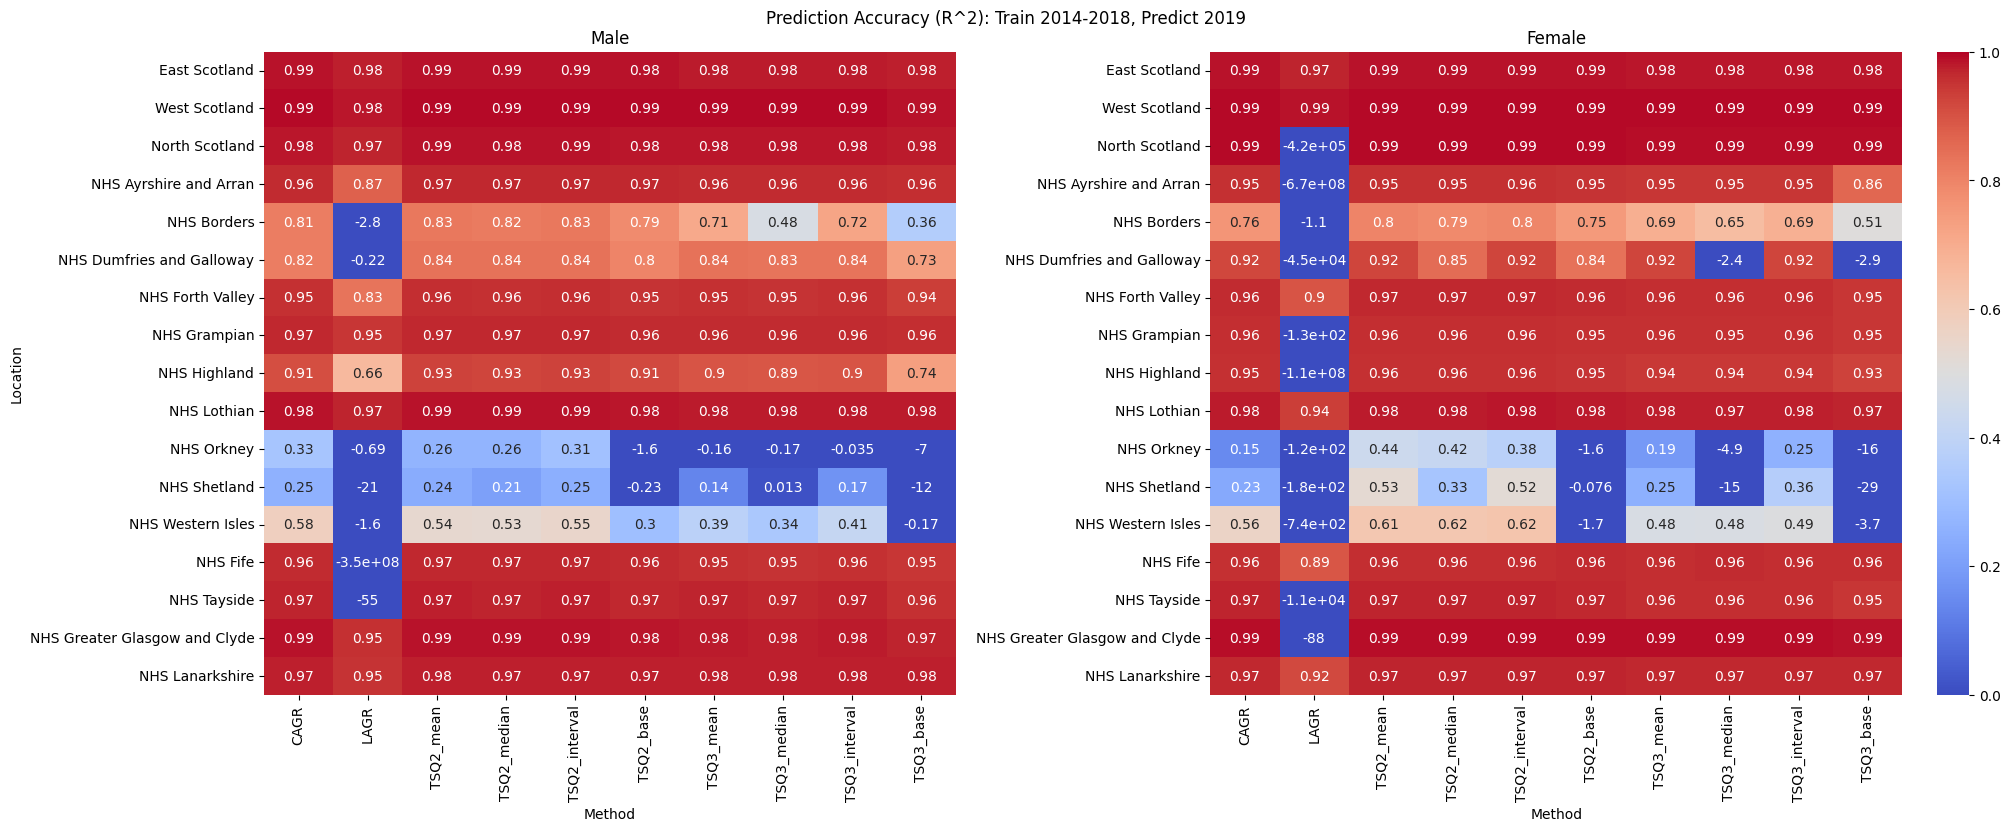

In [9]:
plot_accuracy_heatmap(
    accuracy_df,
    title=f"Prediction Accuracy (R^2): Train 2014-{end_yr}, Predict {end_yr + 1}"
)

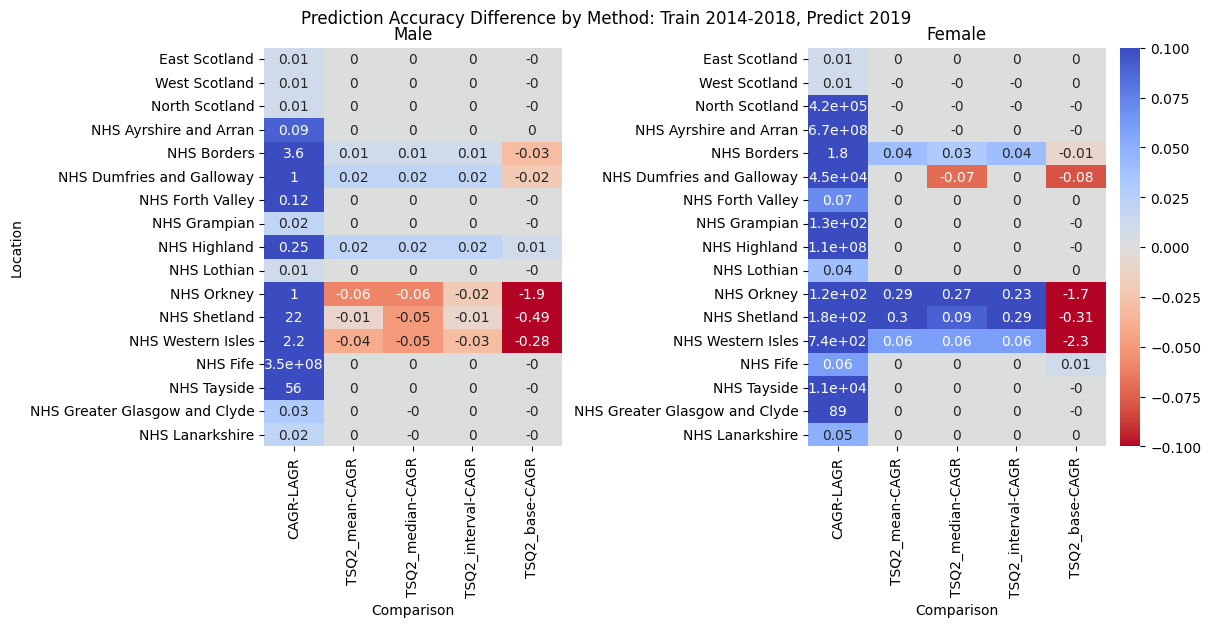

,Location,Sex,CAGR,LAGR,TSQ2_mean,TSQ2_median,TSQ2_interval,TSQ2_base,TSQ3_mean,TSQ3_median,TSQ3_interval,TSQ3_base,CAGR-LAGR,TSQ2_mean-CAGR,TSQ2_median-CAGR,TSQ2_interval-CAGR,TSQ2_base-CAGR
0,East Scotland,Male,0.985492,0.975728,0.986212,0.985865,0.986265,0.984382,0.979907,0.979352,0.980414,0.976522,0.01,0.0,0.0,0.0,-0.0
1,East Scotland,Female,0.985669,0.972220,0.986353,0.986386,0.986495,0.986015,0.983703,0.983772,0.983604,0.982546,0.01,0.0,0.0,0.0,0.0
2,West Scotland,Male,0.994453,0.981182,0.994980,0.994935,0.994981,0.992657,0.992371,0.992279,0.992576,0.987504,0.01,0.0,0.0,0.0,-0.0
3,West Scotland,Female,0.994200,0.987884,0.994097,0.994083,0.994041,0.994242,0.993416,0.993378,0.993483,0.993239,0.01,-0.0,-0.0,-0.0,0.0
4,North Scotland,Male,0.984060,0.970798,0.985302,0.984446,0.985855,0.982455,0.982059,0.980864,0.982902,0.979024,0.01,0.0,0.0,0.0,-0.0


In [10]:
accuracy_comp_2018 = plot_comparison_heatmap(
    accuracy_df,
    title=f"Prediction Accuracy Difference by Method: Train 2014-{end_yr}, Predict {end_yr + 1}"
)
accuracy_comp_2018.head()

In [11]:
method_cols = [col for col in accuracy_df.columns if col not in ["Location", "Sex"]]
accuracy_df[method_cols].mean().sort_values(ascending=False).to_frame("mean_r2")

,mean_r2
TSQ2_interval,8.637070e-01
TSQ2_mean,8.636377e-01
TSQ2_median,8.529277e-01
CAGR,8.444369e-01
TSQ3_interval,8.248358e-01
TSQ3_mean,8.132711e-01
TSQ2_base,6.319098e-01
TSQ3_median,8.917941e-02
TSQ3_base,-1.342888e+00
LAGR,-3.327560e+07


In [12]:
accuracy_df[["Location", "Sex", "CAGR", "LAGR"]].head()

,Location,Sex,CAGR,LAGR
0,East Scotland,Male,0.985492,0.975728
1,East Scotland,Female,0.985669,0.972220
2,West Scotland,Male,0.994453,0.981182
3,West Scotland,Female,0.994200,0.987884
4,North Scotland,Male,0.984060,0.970798


In [13]:
for loc, df_dict in dfs1.items():
    with pd.ExcelWriter(os.path.join(RESULTS_DIR, f"{loc.replace(' ', '_').lower()}_analysis_2018.xlsx")) as writer:
            df_dict["Male"].to_excel(writer, sheet_name="Male", index=False)
            df_dict["Female"].to_excel(writer, sheet_name="Female", index=False)

In [14]:
len([x for x in os.listdir(RESULTS_DIR) if x.endswith("2018.xlsx")])

17

### 2014-2017

In [15]:
# Run the same modular pipeline with training window 2014-2017, predict 2018
end_yr = 2017
dfs2, accuracy_df_2017 = run_growth_pipeline(dfs_source=dfs, start_yr=2014, end_yr=end_yr)
accuracy_df_2017

,Location,Sex,CAGR,LAGR,TSQ2_mean,TSQ2_median,TSQ2_interval,TSQ2_base,TSQ3_mean,TSQ3_median,TSQ3_interval,TSQ3_base
0,East Scotland,Male,0.980720,9.616238e-01,0.983102,0.983191,0.982995,0.982009,0.974600,0.974713,0.974479,0.972045
1,East Scotland,Female,0.981244,-6.936716e+00,0.983509,0.983166,0.983674,0.981994,0.978357,0.977934,0.978431,0.975982
2,West Scotland,Male,0.985904,9.767060e-01,0.986682,0.986663,0.986490,0.986686,0.984781,0.984773,0.984842,0.984854
3,West Scotland,Female,0.986687,-1.590325e+03,0.987968,0.987944,0.988008,0.986383,0.984155,0.984092,0.984278,0.981968
4,North Scotland,Male,0.982678,9.539349e-01,0.985356,0.985339,0.985355,0.984562,0.977339,0.977204,0.977250,0.974918
5,North Scotland,Female,0.981245,9.547421e-01,0.983494,0.983319,0.983433,0.981696,0.977702,0.977376,0.977646,0.974341
6,NHS Ayrshire and Arran,Male,0.928800,-1.303190e+07,0.932934,0.933033,0.933129,0.929778,0.938390,0.938542,0.938569,0.935292
7,NHS Ayrshire and Arran,Female,0.910209,-4.954547e+02,0.965323,0.965715,0.965684,-0.392867,0.957035,0.958487,0.956746,-3.617453
8,NHS Borders,Male,0.816105,4.658824e-01,0.827040,0.822775,0.828420,0.802882,0.821943,0.811837,0.823403,0.781947
9,NHS Borders,Female,0.822339,-1.647198e+01,0.869747,0.867731,0.873660,-0.118070,0.850430,0.842242,0.858611,-6.209999


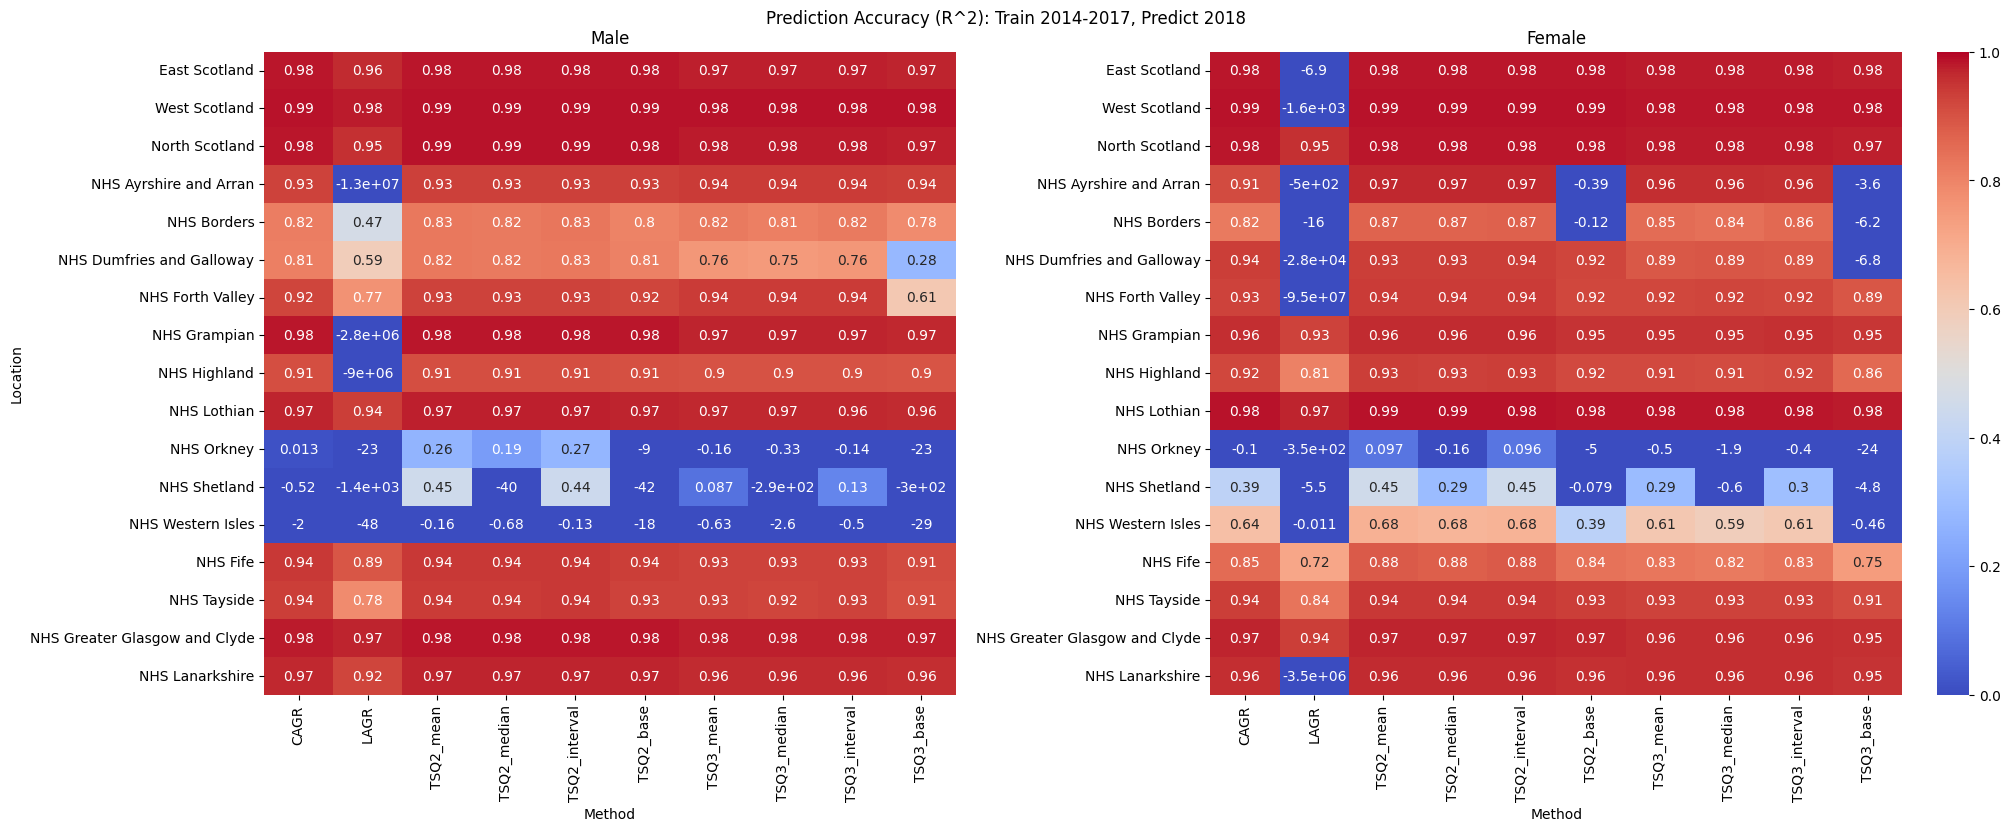

In [16]:
plot_accuracy_heatmap(
    accuracy_df_2017,
    title=f"Prediction Accuracy (R^2): Train 2014-{end_yr}, Predict {end_yr + 1}"
)

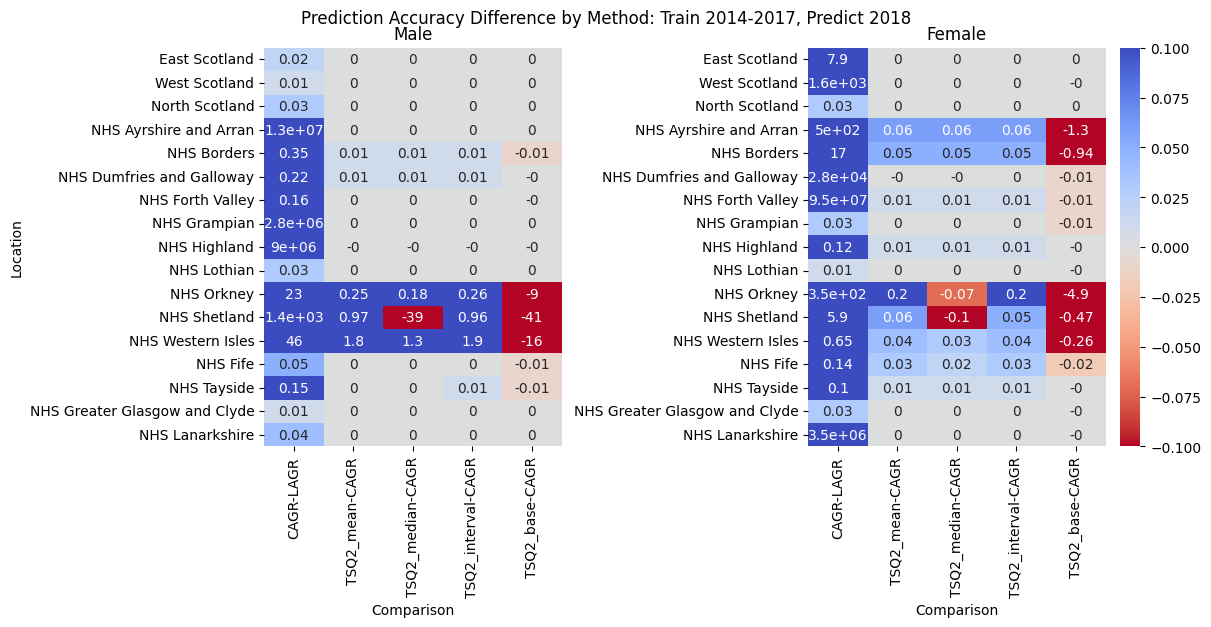

,Location,Sex,CAGR,LAGR,TSQ2_mean,TSQ2_median,TSQ2_interval,TSQ2_base,TSQ3_mean,TSQ3_median,TSQ3_interval,TSQ3_base,CAGR-LAGR,TSQ2_mean-CAGR,TSQ2_median-CAGR,TSQ2_interval-CAGR,TSQ2_base-CAGR
0,East Scotland,Male,0.980720,0.961624,0.983102,0.983191,0.982995,0.982009,0.974600,0.974713,0.974479,0.972045,0.02,0.0,0.0,0.0,0.0
1,East Scotland,Female,0.981244,-6.936716,0.983509,0.983166,0.983674,0.981994,0.978357,0.977934,0.978431,0.975982,7.92,0.0,0.0,0.0,0.0
2,West Scotland,Male,0.985904,0.976706,0.986682,0.986663,0.986490,0.986686,0.984781,0.984773,0.984842,0.984854,0.01,0.0,0.0,0.0,0.0
3,West Scotland,Female,0.986687,-1590.325183,0.987968,0.987944,0.988008,0.986383,0.984155,0.984092,0.984278,0.981968,1591.31,0.0,0.0,0.0,-0.0
4,North Scotland,Male,0.982678,0.953935,0.985356,0.985339,0.985355,0.984562,0.977339,0.977204,0.977250,0.974918,0.03,0.0,0.0,0.0,0.0


In [17]:
accuracy_comp_2017 = plot_comparison_heatmap(
    accuracy_df_2017,
    title=f"Prediction Accuracy Difference by Method: Train 2014-{end_yr}, Predict {end_yr + 1}"
)
accuracy_comp_2017.head()

In [18]:
# Compare method accuracy between the two runs: (2014-2018 -> 2019) minus (2014-2017 -> 2018)
method_cols = [col for col in accuracy_df.columns if col not in ["Location", "Sex"]]

accuracy_compare_runs = accuracy_df.merge(
    accuracy_df_2017,
    on=["Location", "Sex"],
    suffixes=("_train_to_2018", "_train_to_2017")
)

for method in method_cols:
    accuracy_compare_runs[f"{method}_delta"] = (
        accuracy_compare_runs[f"{method}_train_to_2018"] - accuracy_compare_runs[f"{method}_train_to_2017"]
    ).round(2)

delta_cols = ["Location", "Sex"] + [f"{method}_delta" for method in method_cols]
accuracy_delta_df = accuracy_compare_runs[delta_cols]
accuracy_delta_df.head()

,Location,Sex,CAGR_delta,LAGR_delta,TSQ2_mean_delta,TSQ2_median_delta,TSQ2_interval_delta,TSQ2_base_delta,TSQ3_mean_delta,TSQ3_median_delta,TSQ3_interval_delta,TSQ3_base_delta
0,East Scotland,Male,0.00,0.01,0.00,0.00,0.00,0.00,0.01,0.00,0.01,0.00
1,East Scotland,Female,0.00,7.91,0.00,0.00,0.00,0.00,0.01,0.01,0.01,0.01
2,West Scotland,Male,0.01,0.00,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.00
3,West Scotland,Female,0.01,1591.31,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01
4,North Scotland,Male,0.00,0.02,-0.00,-0.00,0.00,-0.00,0.00,0.00,0.01,0.00


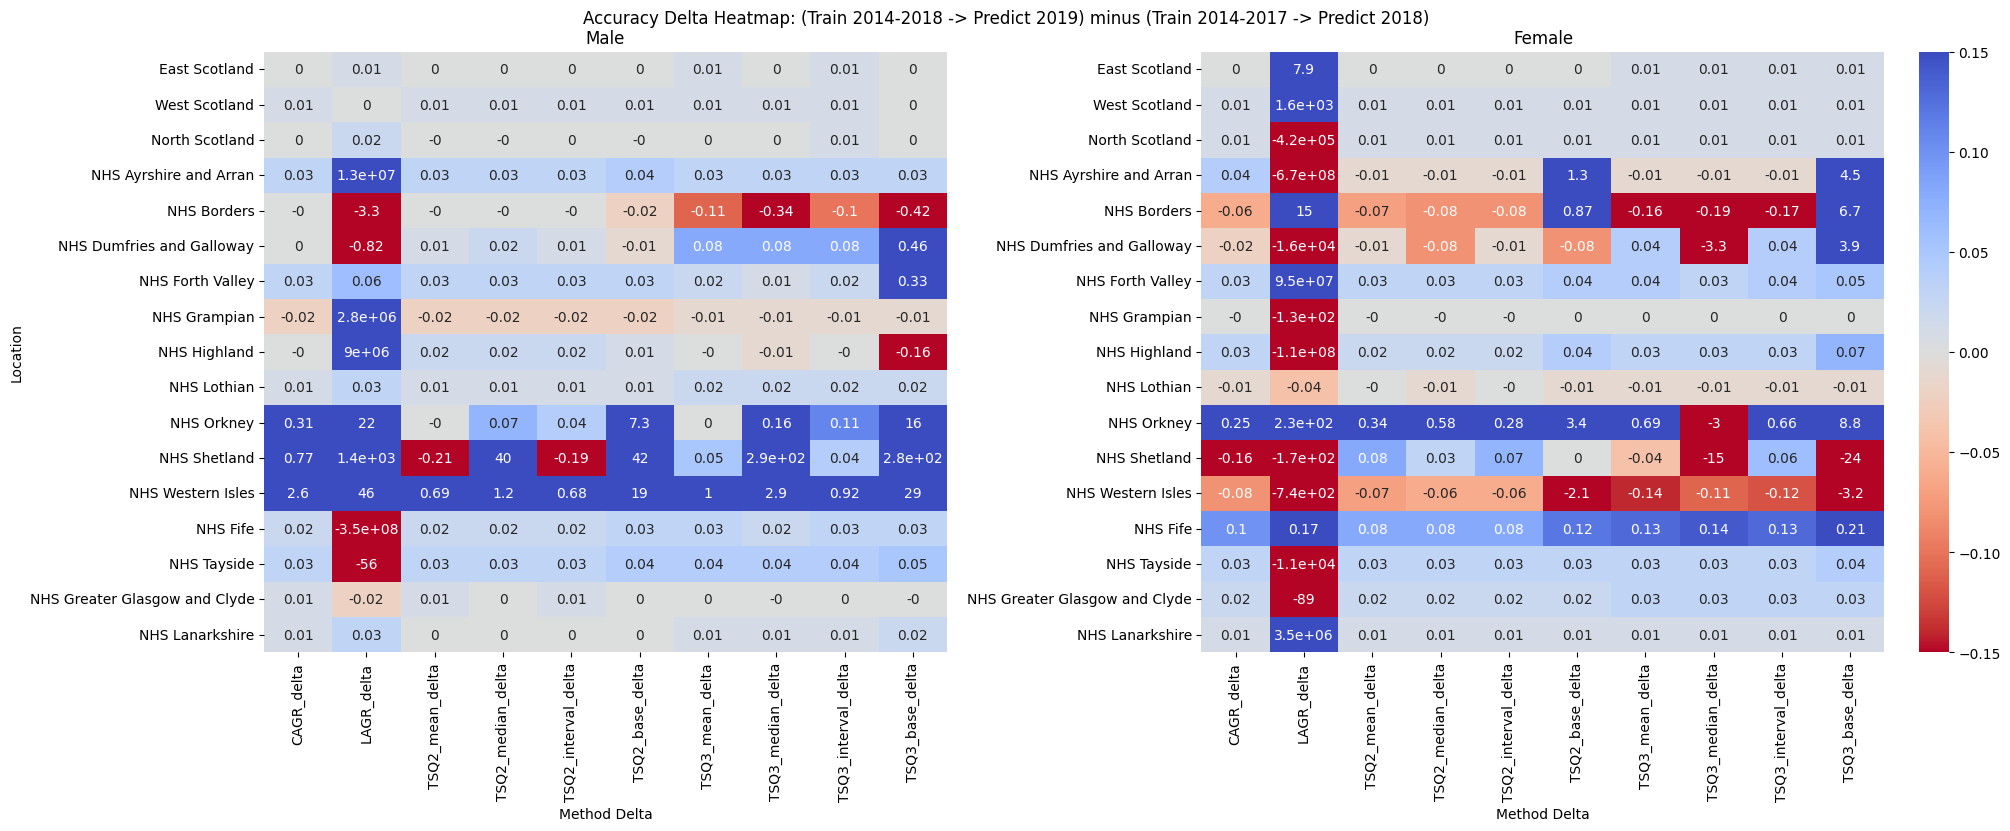

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8), constrained_layout=True)
for ax, sex in zip(axes, ["Male", "Female"]):
    subset = accuracy_delta_df[accuracy_delta_df["Sex"] == sex].set_index("Location").drop(columns=["Sex"])
    sns.heatmap(
        subset,
        annot=True,
        cmap=plt.get_cmap("coolwarm_r"),
        center=0,
        vmin=-0.15,
        vmax=0.15,
        ax=ax,
        cbar=(sex == "Female")
    )
    ax.set_title(sex)
    ax.set_xlabel("Method Delta")
    ax.set_ylabel("Location" if sex == "Male" else "")

fig.suptitle(
    "Accuracy Delta Heatmap: (Train 2014-2018 -> Predict 2019) minus (Train 2014-2017 -> Predict 2018)",
    y=1.02
)
plt.show()

### 2014-2016

In [20]:
# Run the same modular pipeline with training window 2014-2016, predict 2017
end_yr = 2016
dfs2, accuracy_df_2016 = run_growth_pipeline(dfs_source=dfs, start_yr=2014, end_yr=end_yr)
accuracy_df_2016

,Location,Sex,CAGR,LAGR,TSQ2_mean,TSQ2_median,TSQ2_interval,TSQ2_base,TSQ3_mean,TSQ3_median,TSQ3_interval,TSQ3_base
0,East Scotland,Male,0.985675,9.751300e-01,0.985832,0.985803,0.985860,0.984618,0.987175,0.987146,0.987175,0.985115
1,East Scotland,Female,0.983461,9.653561e-01,0.983899,0.984123,0.983794,0.982952,0.977761,0.978304,0.977761,0.975249
2,West Scotland,Male,0.990331,9.769984e-01,0.990488,0.990465,0.990484,0.989922,0.988094,0.987908,0.988094,0.986660
3,West Scotland,Female,0.991789,9.867554e-01,0.991829,0.991761,0.991877,0.991374,0.992531,0.992510,0.992531,0.991767
4,North Scotland,Male,0.976410,-3.346767e+02,0.976224,0.976074,0.976355,0.975535,0.976484,0.976328,0.976484,0.975023
5,North Scotland,Female,0.980331,9.591454e-01,0.980583,0.980630,0.980601,0.979671,0.979290,0.979349,0.979290,0.975912
6,NHS Ayrshire and Arran,Male,0.906067,-4.701876e+04,0.910388,0.904565,0.914308,0.895500,0.860462,0.847534,0.860462,0.818203
7,NHS Ayrshire and Arran,Female,0.617909,-3.453023e+07,0.933093,0.931276,0.934615,-6.307662,0.893095,0.886393,0.893095,-11.529160
8,NHS Borders,Male,0.794129,-3.198236e+09,0.802688,0.799652,0.803658,0.763134,0.753283,0.748080,0.753283,0.665956
9,NHS Borders,Female,0.533637,-1.270904e+00,0.844036,0.283078,0.855641,-4.574187,0.815195,-0.330526,0.815195,-10.563430


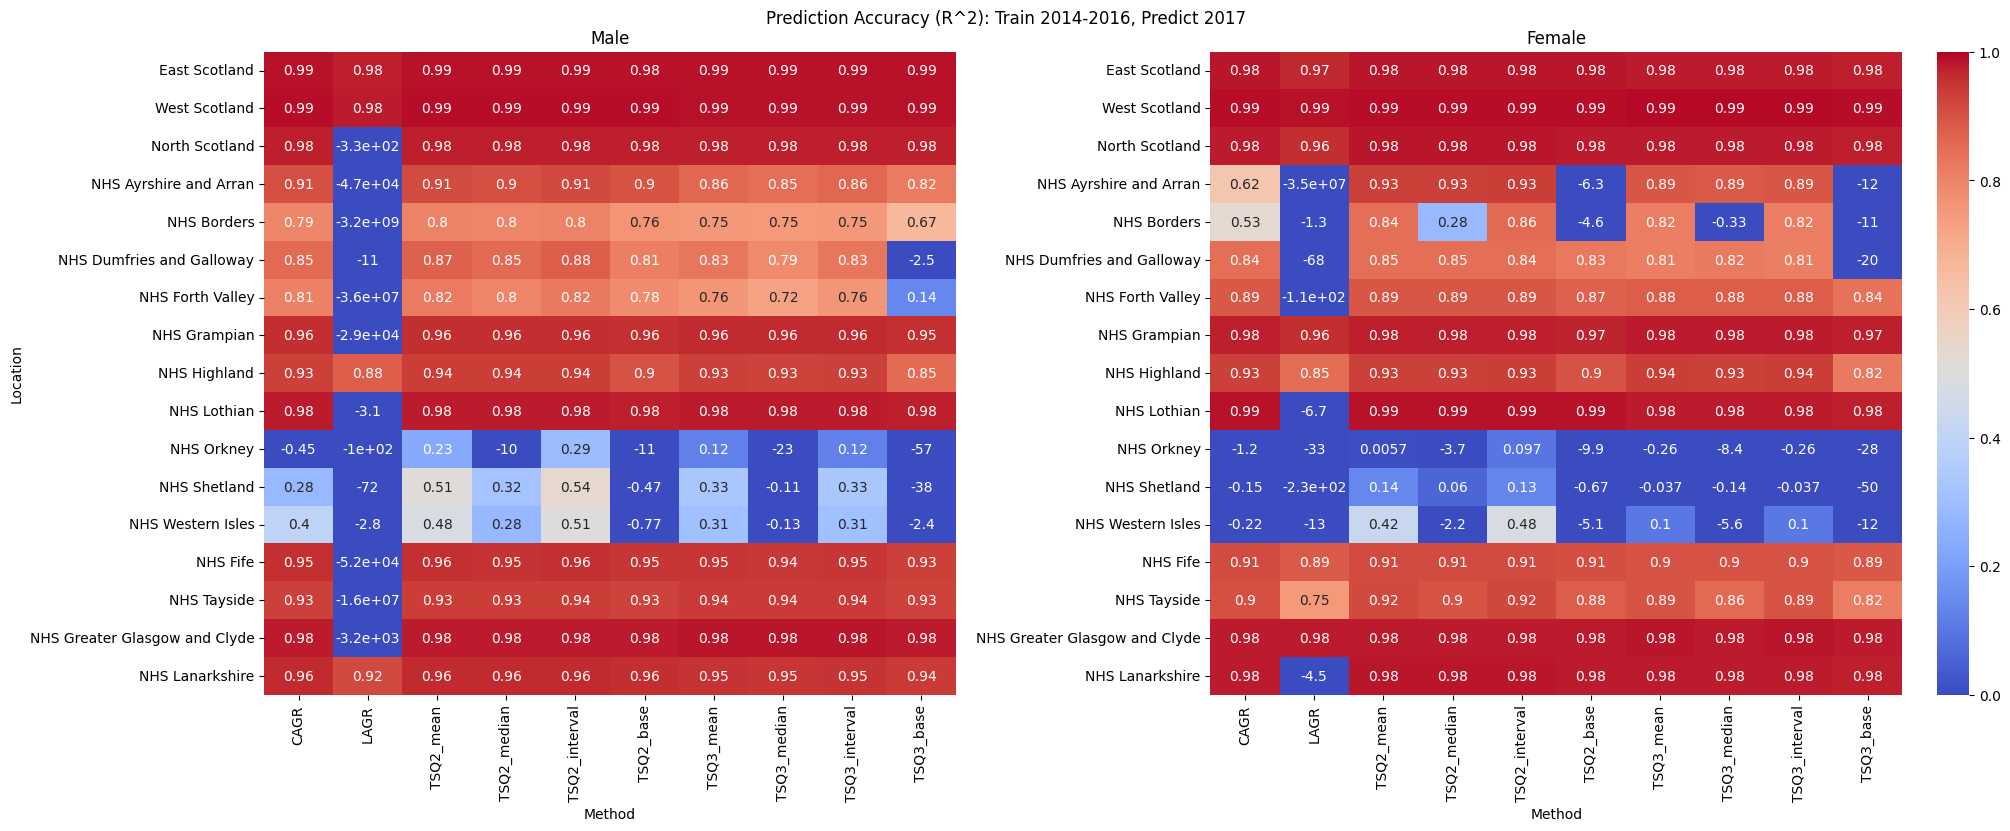

In [21]:
plot_accuracy_heatmap(
    accuracy_df_2016,
    title=f"Prediction Accuracy (R^2): Train 2014-{end_yr}, Predict {end_yr + 1}"
)

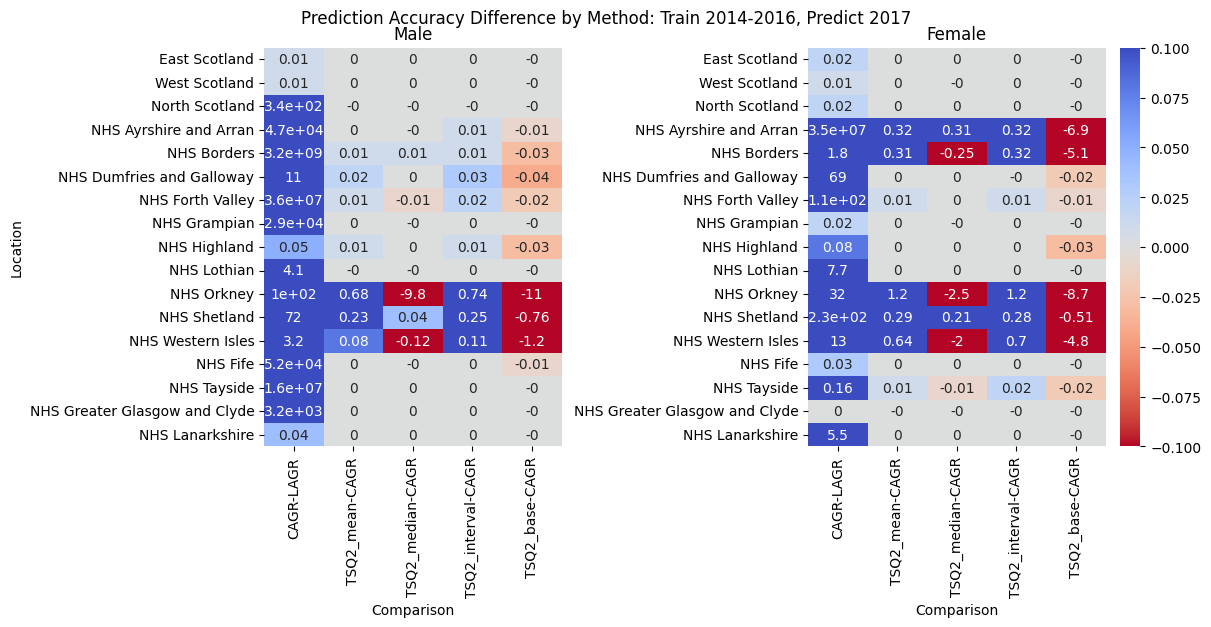

,Location,Sex,CAGR,LAGR,TSQ2_mean,TSQ2_median,TSQ2_interval,TSQ2_base,TSQ3_mean,TSQ3_median,TSQ3_interval,TSQ3_base,CAGR-LAGR,TSQ2_mean-CAGR,TSQ2_median-CAGR,TSQ2_interval-CAGR,TSQ2_base-CAGR
0,East Scotland,Male,0.985675,0.975130,0.985832,0.985803,0.985860,0.984618,0.987175,0.987146,0.987175,0.985115,0.01,0.0,0.0,0.0,-0.0
1,East Scotland,Female,0.983461,0.965356,0.983899,0.984123,0.983794,0.982952,0.977761,0.978304,0.977761,0.975249,0.02,0.0,0.0,0.0,-0.0
2,West Scotland,Male,0.990331,0.976998,0.990488,0.990465,0.990484,0.989922,0.988094,0.987908,0.988094,0.986660,0.01,0.0,0.0,0.0,-0.0
3,West Scotland,Female,0.991789,0.986755,0.991829,0.991761,0.991877,0.991374,0.992531,0.992510,0.992531,0.991767,0.01,0.0,-0.0,0.0,-0.0
4,North Scotland,Male,0.976410,-334.676717,0.976224,0.976074,0.976355,0.975535,0.976484,0.976328,0.976484,0.975023,335.65,-0.0,-0.0,-0.0,-0.0


In [22]:
accuracy_comp_2016 = plot_comparison_heatmap(
    accuracy_df_2016,
    title=f"Prediction Accuracy Difference by Method: Train 2014-{end_yr}, Predict {end_yr + 1}"
)
accuracy_comp_2016.head()